# Airstay Insights
## SageMaker XGBoost Model Training for Airbnb Price Prediction

This notebook loads the Airbnb dataset, cleans and transforms the data, trains an XGBoost regression model in Amazon SageMaker, evaluates performance, and cleans up deployed resources.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
import sagemaker

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator
from sagemaker.image_uris import retrieve

session = sagemaker.Session()
region = session.boto_region_name
role = sagemaker.get_execution_role()
bucket = session.default_bucket()
prefix = "airstay-insights/assignment-5-1"

print("Region:", region)
print("Bucket:", bucket)
print("Role:", role)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Region: us-east-1
Bucket: sagemaker-us-east-1-316001945332
Role: arn:aws:iam::316001945332:role/LabRole


In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


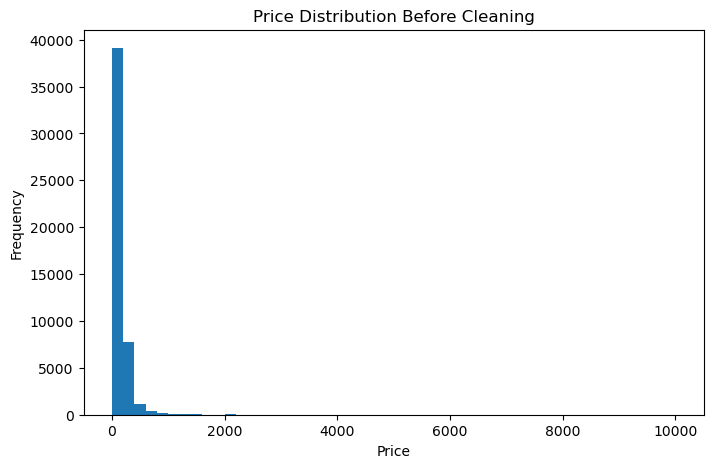

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution Before Cleaning")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

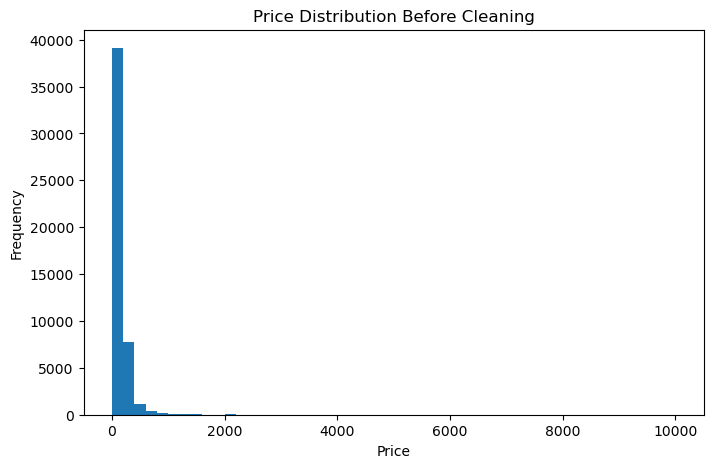

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution Before Cleaning")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [9]:
df = df.drop_duplicates()

df = df.drop(
    columns=["id", "name", "host_id", "host_name", "last_review"],
    errors="ignore"
)

df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

df = df.dropna(subset=["neighbourhood_group", "neighbourhood", "room_type", "price"])

df = df[(df["price"] > 0) & (df["price"] <= 500)]

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (47840, 11)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


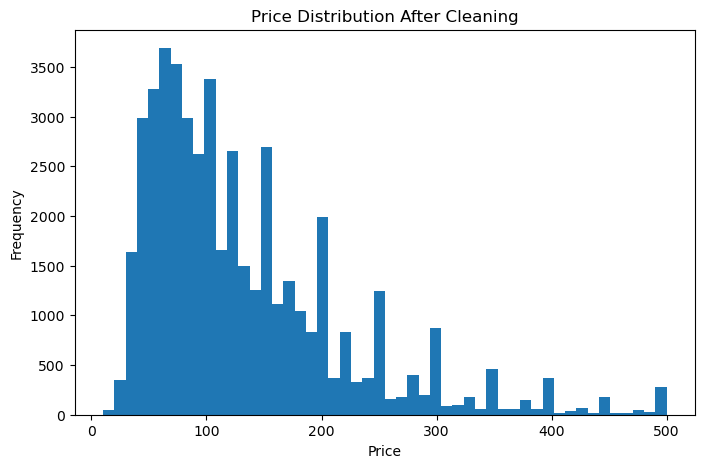

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution After Cleaning")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

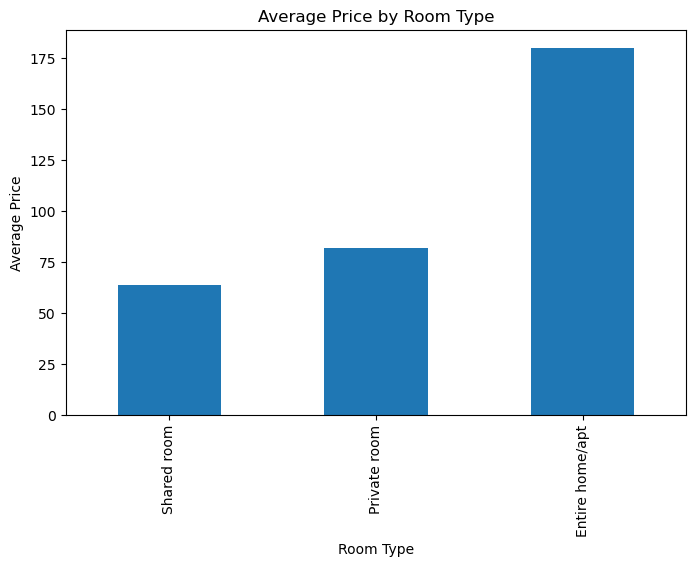

In [11]:
df.groupby("room_type")["price"].mean().sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()

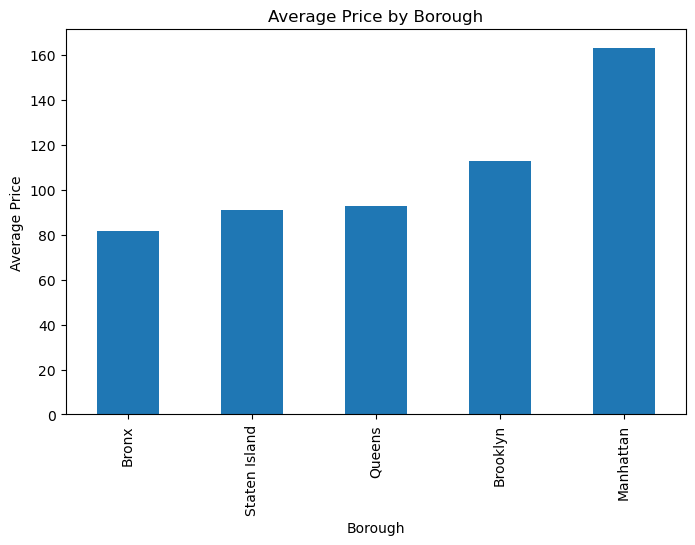

In [12]:
df.groupby("neighbourhood_group")["price"].mean().sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price")
plt.show()

In [13]:
y = df["price"].copy()
X = df.drop(columns=["price"], errors="ignore")

categorical_cols = ["neighbourhood_group", "neighbourhood", "room_type"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (47840, 231)
Target shape: (47840,)


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,...,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,1,9,0.21,6,365,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,40.75362,-73.98377,1,45,0.38,2,355,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,40.80902,-73.94190,3,0,0.00,1,365,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,40.68514,-73.95976,1,270,4.64,1,194,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,40.79851,-73.94399,10,9,0.10,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (30617, 231)
Validation shape: (7655, 231)
Test shape: (9568, 231)


In [15]:
train_df = pd.concat([y_train.reset_index(drop=True), X_train.reset_index(drop=True)], axis=1)
val_df   = pd.concat([y_val.reset_index(drop=True), X_val.reset_index(drop=True)], axis=1)
test_df  = pd.concat([y_test.reset_index(drop=True), X_test.reset_index(drop=True)], axis=1)

train_file = "train.csv"
val_file = "validation.csv"
test_file = "test.csv"

train_df.to_csv(train_file, index=False, header=False)
val_df.to_csv(val_file, index=False, header=False)
test_df.to_csv(test_file, index=False, header=False)

print("Training file shape:", train_df.shape)
print("Validation file shape:", val_df.shape)
print("Test file shape:", test_df.shape)

Training file shape: (30617, 232)
Validation file shape: (7655, 232)
Test file shape: (9568, 232)


In [16]:
train_s3_uri = session.upload_data(path=train_file, bucket=bucket, key_prefix=f"{prefix}/train")
val_s3_uri = session.upload_data(path=val_file, bucket=bucket, key_prefix=f"{prefix}/validation")
test_s3_uri = session.upload_data(path=test_file, bucket=bucket, key_prefix=f"{prefix}/test")

print("Train S3 URI:", train_s3_uri)
print("Validation S3 URI:", val_s3_uri)
print("Test S3 URI:", test_s3_uri)

Train S3 URI: s3://sagemaker-us-east-1-316001945332/airstay-insights/assignment-5-1/train/train.csv
Validation S3 URI: s3://sagemaker-us-east-1-316001945332/airstay-insights/assignment-5-1/validation/validation.csv
Test S3 URI: s3://sagemaker-us-east-1-316001945332/airstay-insights/assignment-5-1/test/test.csv


In [17]:
container = retrieve(
    framework="xgboost",
    region=region,
    version="1.7-1"
)

xgb = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/{prefix}/output",
    sagemaker_session=session
)

xgb.set_hyperparameters(
    objective="reg:squarederror",
    num_round=200,
    max_depth=5,
    eta=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse"
)

print("Estimator configured successfully.")

Estimator configured successfully.


In [18]:
xgb.fit({
    "train": TrainingInput(train_s3_uri, content_type="text/csv"),
    "validation": TrainingInput(val_s3_uri, content_type="text/csv")
})

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-04-02-01-25-47-228


2026-04-02 01:25:49 Starting - Starting the training job...
2026-04-02 01:26:05 Starting - Preparing the instances for training...
2026-04-02 01:26:26 Downloading - Downloading input data...
2026-04-02 01:27:17 Downloading - Downloading the training image......
2026-04-02 01:28:23 Training - Training image download completed. Training in progress..../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-02 01:28:24.906 ip-10-0-250-208.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-04-02 01:28:24.974 ip-10-0-250-208.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-04-02:01:28:25:INFO] Imported framework sagemaker_xgboost_container.tra

In [19]:
predictor = xgb.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    serializer=sagemaker.serializers.CSVSerializer(),
    deserializer=sagemaker.deserializers.CSVDeserializer()
)

print("Endpoint name:", predictor.endpoint_name)

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-04-02-01-30-20-091
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-04-02-01-30-20-091
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-04-02-01-30-20-091


------!Endpoint name: sagemaker-xgboost-2026-04-02-01-30-20-091


In [20]:
X_test_for_pred = X_test.copy().values

batch_size = 500
all_predictions = []

for i in range(0, len(X_test_for_pred), batch_size):
    batch = X_test_for_pred[i:i+batch_size]
    batch_pred = predictor.predict(batch)
    batch_pred = np.array(batch_pred).astype(float).flatten()
    all_predictions.extend(batch_pred)

y_pred = np.array(all_predictions)

print("Number of predictions:", len(y_pred))
print("First 10 predictions:", y_pred[:10])

Number of predictions: 9568
First 10 predictions: [ 68.31336212  52.37826538 272.0473938  172.9825592  184.50701904
 155.27333069 303.36297607 137.47160339 190.14865112 104.1077652 ]


In [21]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 61.103137521909645
MAE: 40.67869569964233
R2: 0.5166879635973345


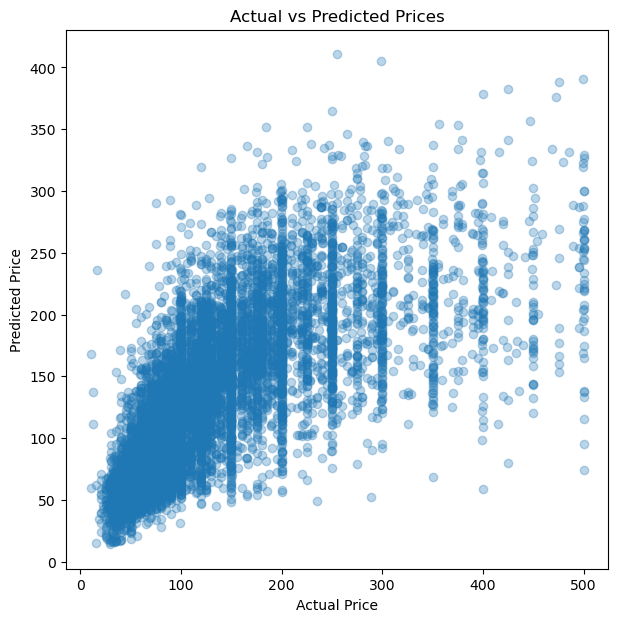

In [22]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [23]:
results_df = pd.DataFrame({
    "Actual Price": y_test.reset_index(drop=True),
    "Predicted Price": y_pred
})

results_df.head(10)

,Actual Price,Predicted Price
0,60,68.313362
1,55,52.378265
2,250,272.047394
3,125,172.982559
4,100,184.507019
5,75,155.273331
6,175,303.362976
7,84,137.471603
8,148,190.148651
9,80,104.107765


In [24]:
try:
    predictor.delete_endpoint()
    print("Endpoint deleted.")
except Exception:
    print("Endpoint/config already deleted or not found.")

print("Cleanup step finished.")

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-04-02-01-30-20-091
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2026-04-02-01-30-20-091


Endpoint deleted.
Cleanup step finished.
